In [3]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import cv2
import torchvision.transforms.v2 as T
import os
import pandas as pd
from torchvision.io import decode_image
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

In [1]:

img_dir = '/Users/amirhamidullin/Downloads/bhw1/trainval'
test_dir = '/Users/amirhamidullin/Downloads/bhw1/test'

labels_file = '/Users/amirhamidullin/Downloads/bhw1/labels.csv'
submission_file = '/Users/amirhamidullin/Downloads/bhw1/sample_submission.csv'


In [ ]:
class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = annotations_file
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = cv2.imread(img_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

 


/Users/amirhamidullin/PycharmProjects/DL/.venv/lib/python3.13/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [5]:
data = pd.read_csv(labels_file)
df_train, df_valid = train_test_split(data, test_size = 0.2, random_state = 42, stratify= data.Category)
df_test = pd.read_csv(submission_file)

dataset_train = CustomImageDataset(df_train, img_dir,transform = test_transform, target_transform = None)
dataset_val = CustomImageDataset(df_valid, img_dir,transform = test_transform, target_transform = None)
dataset_test = CustomImageDataset(df_test, test_dir, transform=test_transform, target_transform=None)

train_loader = (DataLoader(dataset_train, batch_size=32, shuffle=True))
val_loader = (DataLoader(dataset_val, batch_size=32, shuffle=False))
test_loader = (DataLoader(dataset_test, batch_size=32, shuffle=False)) 

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 2500
Val batches: 625
Test batches: 313


In [6]:
images, labels = next(iter(train_loader))  
print(f"Labels dtype: {labels.dtype}")
print(f"Labels: {labels[:5]}")

Labels dtype: torch.int64
Labels: tensor([127, 104,  67, 175, 135])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6301525..2.622571].


Размер батча картинок: torch.Size([32, 3, 40, 40])
Размер батча меток: torch.Size([32])
Пример меток: tensor([147, 186, 115,  35, 137])


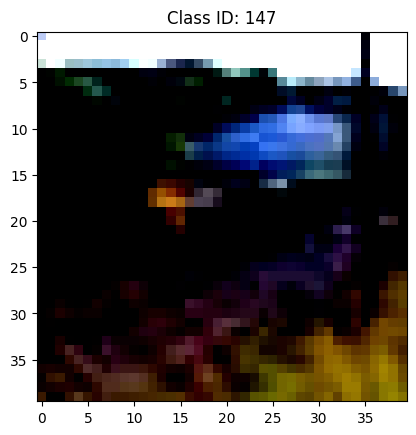

In [ ]:
import matplotlib.pyplot as plt


images, labels = next(iter(train_loader))

print(f"Размер батча картинок: {images.shape}") 
print(f"Размер батча меток: {labels.shape}")    
print(f"Пример меток: {labels[:5]}")

img_to_show = images[0].permute(1, 2, 0) 
plt.imshow(img_to_show)
plt.title(f"сlass  {labels[0].item()}")
plt.show()

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.notebook import tqdm


sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 15})


def plot_losses(train_losses, test_losses, train_accuracies, test_accuracies):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(test_losses) + 1), test_losses, label='test')
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_accuracies) + 1), train_accuracies, label='train')
    axs[1].plot(range(1, len(test_accuracies) + 1), test_accuracies, label='test')
    axs[1].set_ylabel('accuracy')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [ ]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    model.train()
    train_loss, train_accuracy = 0.0, 0.0
    for batch, labels in tqdm(train_loader): 
        batch = batch.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        logits = model(batch) # дошли по графу и получили матрицу batch_size x num classes
        loss = criterion(logits, labels) # от него loss
        loss.backward() # идем назад чтобы изменить веса 
        optimizer.step()

        train_loss += loss.item() * batch.shape[0] # на один батч
        train_accuracy += (logits.argmax(dim=1)==labels).sum().item() # на один батч
    
    # среднняя ошибка на картинку 
    train_loss = train_loss/len(dataset_train)
    train_accuracy = train_accuracy/len(dataset_train)

    return train_loss, train_accuracy

@torch.no_grad()
def validation_epoch(model, criterion, test_loader, tqdm_desc):
    model.eval()
    val_loss, val_accuracy = 0.0, 0.0
    for batch, labels in tqdm(val_loader):
        batch = batch.to(device)
        labels = labels.to(device)
        logits = model(batch)
        loss = criterion(logits, labels)
        
        val_loss += loss.item() * batch.shape[0] # на один батч
        val_accuracy += (logits.argmax(dim=1)==labels).sum().item() # на один батч
    
    val_loss /= len(dataset_val)
    val_accuracy /= len(dataset_val)

    return val_loss, val_accuracy



def train(model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs):
    train_losses, train_accuracies = [], []
    test_losses, test_accuracies = [], []

    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        test_loss, test_accuracy = validation_epoch(
            model, criterion, test_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        if scheduler is not None:
            scheduler.step()

        train_losses += [train_loss]
        train_accuracies += [train_accuracy]
        test_losses += [test_loss]
        test_accuracies += [test_accuracy]
        plot_losses(train_losses, test_losses, train_accuracies, test_accuracies)
        print(f'эпоха {epoch} train acc={train_acc}, val acc={val_acc}')

    return train_losses, test_losses, train_accuracies, test_accuracies    
    







In [10]:
len(data["Category"].unique())

200

In [11]:
import torch.nn as nn
import torch.nn.functional as F

class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.linear = nn.Linear(32, 200) # считали сами

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))

        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.linear(x)

        return x

In [12]:
device = 'cpu'

In [13]:
model = ConvNet().to(device)
num_epochs = 10
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

In [ ]:
model.eval()
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

print(f"Labels dtype: {labels.dtype}")  
print(f"Labels sample: {labels[:5]}")

logits = model(images)
print(f"Logits shape: {logits.shape}")  # [batch_size, 200]
print(f"Logits sample: {logits[0, :5]}")  

Labels dtype: torch.int64
Labels sample: tensor([ 98, 138, 176, 191,  35])
Logits shape: torch.Size([32, 200])
Logits sample: tensor([ 0.1351,  0.0484,  0.1035, -0.1224, -0.1961], grad_fn=<SliceBackward0>)


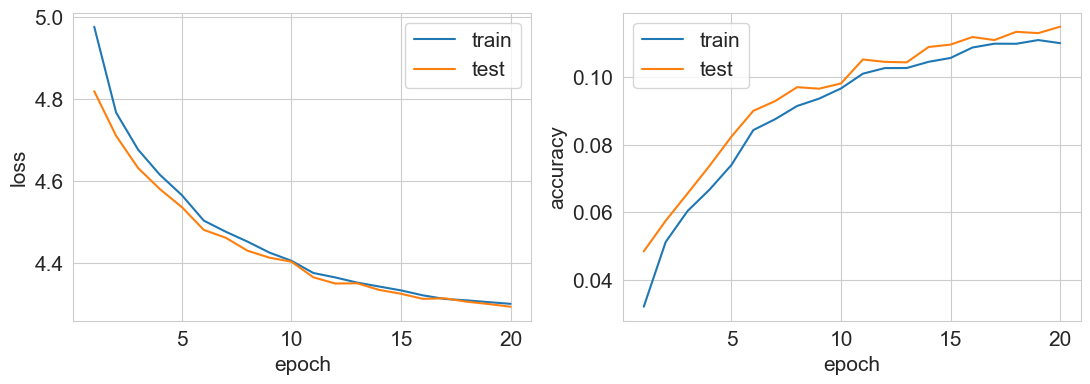

In [19]:

NUM_EPOCHS = 20
LR = 1e-3

model = ConvNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

train_losses, val_losses, train_accs, val_accs = train(
    model, optimizer, scheduler, criterion, train_loader, val_loader, NUM_EPOCHS
)

In [20]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    predictions = []
    for images, _ in tqdm(loader, desc="predicting"):
        images = images.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1)
        predictions.extend(preds.cpu().numpy())
    return predictions
predictions = predict(model, test_loader)

submission = pd.read_csv(submission_file)
submission['Category'] = predictions
submission.to_csv('submission.csv', index=False)

predicting:   0%|          | 0/313 [00:00<?, ?it/s]

In [21]:
val_accs[-1]

0.1149